In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymoo.core.problem import Problem

In [6]:
from pathlib import Path
ROOT = Path().resolve().parents[1]
data_path = ROOT / 'src' / 'data' / 'dataset.xlsx'
df = pd.read_excel(data_path)
df.head()

,datetime,i_sc,v_oc,i_mp,v_mp,p_mp,i_x,i_xx,"Сасыр, kW","Solar, kW"
0,2019-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,201.000791,0.0
1,2019-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,179.721422,0.0
2,2019-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,171.304978,0.0
3,2019-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,173.068636,0.0
4,2019-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,159.528222,0.0


In [1]:
from src.components.Battery import Battery
CAPACITY = 176
SOC_MAX = 100
SOC_MIN = 20
R_POWER_CH = 176
R_POWER_DS = 176
EFF_CH = 98
EFF_DS = 98
CP = 2
BESS = (
    Battery(
        capacity= CAPACITY,
        soc_max = SOC_MAX,
        soc_min = SOC_MIN,
        r_power_ch = R_POWER_CH,
        r_power_ds = R_POWER_DS,
        eff_ch = EFF_CH,
        eff_ds = EFF_DS,
        cp = CP
    )
)

In [2]:
from src.components.DieselGenerator import DieselGenerator
N_DGs = 4
R_CAPACITY = 110
a1, a2 = 0.0101, 0.2654
START_STOP_PRICE = 4
FUEL_PRICE = 54.6 # руб./кг
DGs = (
    DieselGenerator(
        num_DGs = N_DGs,
        gen_capacity = R_CAPACITY,
        a1 = a1, a2 = a2,
        fuel_price = FUEL_PRICE
    )
)

In [7]:
from src.simulator.MicrogridSimulator import MicrogridSimulator
LABEL_LOAD = 'Сасыр, kW'
LABEL_GEN = 'Solar, kW'
MS = MicrogridSimulator(
    df,
    LABEL_LOAD,
    LABEL_GEN,
    BESS,
    DGs
)
INIT_SOC = 0.5
INIT_DGs = np.array([1,1,0,0], dtype=np.float64)

In [8]:
res_1 = MS.simulator_1(INIT_SOC,INIT_DGs)
res_1['cost_dgs_history'].sum()

np.float64(11941587.375133853)

In [9]:
res_2 = MS.simulator_2(INIT_SOC,INIT_DGs)
res_2['cost_dgs_history'].sum()

np.float64(11940261.670797665)

In [10]:
res_2['p_bess_history']

array([48.224,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ])

In [11]:
res_3 = MS.simulator_3(INIT_DGs)
res_3['cost_dgs_history'].sum()

np.float64(12369351.863820214)

In [12]:
res_2['p_dgs_history']

array([152.77679137, 179.72142183, 171.30497811, ..., 240.64557608,
       200.35855629, 183.20879694])

In [13]:
res_3['p_dgs_history']

array([201.00079137, 179.72142183, 171.30497811, ..., 240.64557608,
       200.35855629, 183.20879694])

In [10]:
df['Сасыр, kW'].mean()

np.float64(160.76382152593183)

In [11]:
df['Solar, kW'].mean()

np.float64(91.87561237127687)

In [12]:
df['Month'] = df['datetime'].dt.strftime('%b')
df['Month_Num'] = df['datetime'].dt.month
loads = [df[df['Month'] == month]['Сасыр, kW'] for month in df['Month']
.unique()]
labels = ['ЯНВ', 'ФЕВ', 'МАР', 'АПР', 'МАЙ', 'ИЮН',
          'ИЮЛ', 'АВГ', 'СЕН', 'ОКТ', 'НОЯ', 'ДЕК']

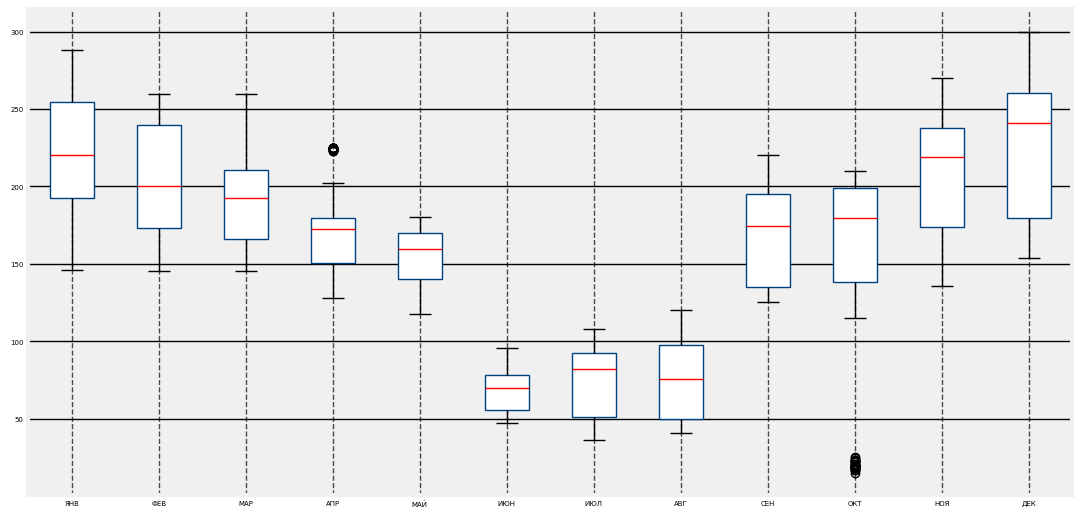

<Figure size 640x480 with 0 Axes>

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
ROOT = Path().resolve().parents[1]
name = 'matplotlib_loads'
plt.style.use("fivethirtyeight")

mpl.rcParams['font.size'] = 5
mpl.rcParams['grid.color'] = "black"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

bp = ax.boxplot(loads, patch_artist=True,
                boxprops=dict(facecolor='#FFFFFF', color='#004080'),
                medianprops=dict(color='red'),
                tick_labels=labels)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

data_path = ROOT / 'src' / 'plots' / f'{name}.png'
plt.savefig(data_path, dpi=300)


In [14]:
day_winter=df.query("'2019-01-18 00:00:00' <= datetime < '2019-01-19 00:00:00'")
day_summ=df.query("'2019-07-19 00:00:00' <= datetime < '2019-07-20 00:00:00'")

In [52]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
ROOT = Path().resolve().parents[1]
name = 'plotly_loads'

fig = make_subplots(rows=2, cols=1, horizontal_spacing=0.02,
                    vertical_spacing=0.15)
fig.add_trace(
    go.Scatter(x=day_winter['datetime'], y=day_winter['Сасыр, kW'],
               name='Потребляемая мощность зимой',
               line=dict(color='#4169E1', width=3), textposition='top center',
               fill='tozeroy'),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=day_winter['datetime'], y=day_summ['Сасыр, kW'],
               name='Потребляемая мощность летом',
               line=dict(color='#76A912', width=3), textposition='top center',
               fill='tozeroy'),
    row=1, col=1
)
for inx, series in enumerate(loads):
    fig.add_trace(
        go.Box(y=series, name=labels[inx], showlegend=False,
               marker=dict(color="#4169E1"), line=dict(color="#4169E1")),
        row=2, col=1
    )

fig.update_layout(
    legend=dict(orientation="h",
                 yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=0.70),
     width=1550,
     height=950,
     template="plotly_white",
     title_font_family="bold",
     title_font_color="black",
     legend_title_font_color="black",
     legend_title_font_family = "bold" ,
     autosize=False,
     plot_bgcolor='rgba(245,40,145,0)',
     legend_font_size=30,
     legend_font_color='black',
     title_font_size=35
)
fig.update_xaxes(title_font=dict(color='black', size=50, family='bold'),
                 tickfont_size=25, tickfont_color='black',
                 tickfont_family='bold', row=1, col=1, showgrid=True,
                 tickformat='%H:00',
                 gridcolor='lightgray', gridwidth=0.5, mirror=True, linecolor='black', linewidth=1)
fig.update_xaxes(title_font=dict(color='black', size=50, family='bold'),
                 tickfont_size=25, tickfont_color='black',title_text='2019',
                 tickfont_family='bold', row=2, col=1,  showgrid=True,
                 gridcolor='lightgray', gridwidth=0.5, mirror=True, linecolor='black', linewidth=1)
fig.update_yaxes(tickfont_size=25,tickfont_color='black',
                 tickfont_family='bold',tickformat=',.0f', row=1, col=1,
                 showgrid=True, gridcolor='lightgray', gridwidth=0.5, mirror=True,  linecolor='white', linewidth=1)
fig.update_yaxes(tickfont_size=25,tickfont_color='black',
                 tickfont_family='bold',tickformat=',.0f', row=2, col=1,
                 showgrid=True, gridcolor='lightgray', gridwidth=0.5, mirror=True,  linecolor='white', linewidth=1)

fig.update_annotations(font_size=35, font_color='black')
fig.update_layout(separators="* .*")
fig.show()

data_path = ROOT / 'src' / 'plots' / f'{name}.png'
fig.write_image(data_path)

In [15]:
from pathlib import Path
ROOT = Path().resolve().parents[1]
data_path = ROOT / 'src' / 'data' / 'weather.csv'
data = pd.read_csv(data_path)
data.rename(columns={'Unnamed: 0': 'datetime'}, inplace=True)
data['datetime'] = pd.to_datetime(data['datetime'])
data['datetime'] = pd.to_datetime(data['datetime']).dt.tz_convert('Asia/Krasnoyarsk')
data[['dni', 'dhi', 'ghi']] = data[['dni', 'dhi', 'ghi']] * 1e-3
print(data)

                      datetime      dni      dhi      ghi  temp_air  \
0    2018-12-31 07:00:00+07:00  0.00000  0.00000  0.00000    -19.85   
1    2018-12-31 08:00:00+07:00  0.00000  0.00000  0.00000    -20.05   
2    2018-12-31 09:00:00+07:00  0.03999  0.02073  0.01838    -19.97   
3    2018-12-31 10:00:00+07:00  0.09412  0.06096  0.07762    -18.79   
4    2018-12-31 11:00:00+07:00  0.11979  0.10409  0.13602    -16.87   
...                        ...      ...      ...      ...       ...   
8803 2020-01-02 02:00:00+07:00  0.00000  0.00000  0.00000    -22.30   
8804 2020-01-02 03:00:00+07:00  0.00000  0.00000  0.00000    -22.32   
8805 2020-01-02 04:00:00+07:00  0.00000  0.00000  0.00000    -22.30   
8806 2020-01-02 05:00:00+07:00  0.00000  0.00000  0.00000    -22.28   
8807 2020-01-02 06:00:00+07:00  0.00000  0.00000  0.00000    -22.29   

      wind_speed  
0           1.76  
1           1.74  
2           1.86  
3           1.91  
4           1.61  
...          ...  
8803        4.

In [16]:
data_day_winter = data.query("'2019-01-18 00:00:00+07:00' <= datetime < "
                             "'2019-01-19 00:00:00+07:00'", inplace=False)
data_day_sum = data.query("'2019-07-19 00:00:00+07:00' <= datetime < '2019-07-20 00:00:00+07:00'", inplace=False)

In [17]:
data['date'] = pd.to_datetime(data['datetime']).dt.date
daily = data.groupby('date').agg({
    'dni': 'sum',
    'dhi': 'sum',
    'ghi': 'sum',
    'temp_air': 'mean',
    'wind_speed': 'mean'
}).reset_index()

daily['Month'] = pd.to_datetime(daily['date']).dt.strftime('%b')

data_year = daily.groupby('Month')[['dni', 'dhi', 'ghi', 'temp_air',
                                    'wind_speed']].mean()
month_map = {
    'Jan': 'ЯНВ', 'Feb': 'ФЕВ', 'Mar': 'МАР', 'Apr': 'АПР',
    'May': 'МАЙ', 'Jun': 'ИЮН', 'Jul': 'ИЮЛ', 'Aug': 'АВГ',
    'Sep': 'СЕН', 'Oct': 'ОКТ', 'Nov': 'НОЯ', 'Dec': 'ДЕК'
}
data_year.index = data_year.index.map(month_map)
months_order = ['ЯНВ', 'ФЕВ', 'МАР', 'АПР', 'МАЙ', 'ИЮН', 'ИЮЛ', 'АВГ', 'СЕН', 'ОКТ', 'НОЯ', 'ДЕК']
data_year.index = pd.Categorical(data_year.index, categories=months_order, ordered=True)
data_year = data_year.sort_index()

In [12]:
data_year

,dni,dhi,ghi,temp_air,wind_speed
ЯНВ,2.770628,0.629857,1.257470,-21.045800,3.141282
ФЕВ,3.468485,1.054170,2.132052,-19.919747,3.008943
МАР,4.781719,1.787372,3.775655,-8.686895,2.972755
АПР,4.312719,2.659896,4.913236,-1.369556,5.030806
МАЙ,5.818368,2.787803,6.155275,2.118884,4.343911
ИЮН,4.783277,2.873009,5.918715,9.889514,3.238347
ИЮЛ,4.022557,2.528864,5.165664,11.378132,2.630242
АВГ,5.762868,1.947031,5.206781,11.033306,2.748952
СЕН,3.842167,1.741564,3.593328,4.954889,3.348625
ОКТ,5.110083,0.849281,2.756576,-2.542809,3.898737


In [18]:
from enum import Enum
from pathlib import Path
from plotly.subplots import make_subplots
import plotly.graph_objects as go

ROOT = Path().resolve().parents[1]
name = 'plotly_loads'

class TraceParam(Enum):
    DNI = ('dni', '#4169E1')
    DHI = ('dhi', '#FF0000')
    GHI = ('ghi', '#E16941')

seasons = [('winter', data_day_winter, 1), ('summer', data_day_sum, 2)]

fig = make_subplots(rows=2, cols=2, horizontal_spacing=0.05,
                    vertical_spacing=0.1,
                    specs=[
                    [{}, {}],
                    [{"colspan": 2}, None]
    ]
                    )

for season_label, data, col in seasons:
    for trace in TraceParam:
        name, color = trace.value
        fig.add_trace(
            go.Scatter(x=data['datetime'], y=data[name], name=name.upper(),
                       line=dict(color=color, width=3),
                       textposition='top center'),
            row=1, col=col
        )

for trace in TraceParam:
    name, color = trace.value
    fig.add_trace(
        go.Scatter(x=data_year.index, y=data_year[name], name=name.upper(),
                   line=dict(color=color, width=3),
                   showlegend=False),   # скрываем дублирование легенды
        row=2, col=1
    )

# Общие настройки осей
axis_config = {
    'tickfont_size': 25,
    'tickfont_color': 'black',
    'tickfont_family': 'bold',
    'showgrid': True,
    'gridcolor': 'lightgray',
    'gridwidth': 0.5,
    'mirror': True,
    'linewidth': 1
}
xaxis_config = {**axis_config, 'tickformat': '%H:00', 'linecolor': 'black'}
yaxis_config = {**axis_config, 'tickformat': '1f', 'linecolor': 'white'}

for col in (1, 2):
    fig.update_xaxes(title_font=dict(color='black', size=50, family='bold'),
                     **xaxis_config, row=1, col=col)
    fig.update_yaxes(**yaxis_config, row=1, col=col)

fig.update_xaxes(title_font=dict(color='black', size=50, family='bold'),
                 **axis_config,
                 row=2, col=1)
fig.update_yaxes(**yaxis_config, row=2, col=1)

fig.update_layout(
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=0.70),
    width=1550, height=950, template="plotly_white", autosize=False,
    plot_bgcolor='rgba(245,40,145,0)',
    legend_font_size=25, legend_font_color='black',
    title_font_size=35, title_font_family="bold", title_font_color="black",
    legend_title_font_color="black", legend_title_font_family="bold",
    separators="* .*"
)
fig.update_annotations(font_size=35, font_color='black')
fig.show()

In [19]:
from enum import Enum
from pathlib import Path
from plotly.subplots import make_subplots
import plotly.graph_objects as go

ROOT = Path().resolve().parents[1]
name_plot = 'plotly_gen'

class TraceParam(Enum):
    DNI = ('dni', False, '#4169E1')
    DHI = ('dhi', False, '#FF0000')
    GHI = ('ghi', False, '#008000')
    WS = ('wind_speed', True, '#CFBF64')
    # TA = ('temp_air', True, '#2B1700')

secondary_color = next(trace.value[2] for trace in TraceParam if trace.value[1] is True)

seasons = [('winter', data_day_winter, 1), ('summer', data_day_sum, 2)]

fig = make_subplots(rows=2, cols=2, horizontal_spacing=0.15,
                    vertical_spacing=0.15,
                    specs=[[{"secondary_y": True}, {"secondary_y": True}],
                           [{"colspan": 2, "secondary_y": True}, None]])

for season_label, data, col in seasons:
    for trace in TraceParam:
        name, secondary, color = trace.value
        fig.add_trace(
            go.Scatter(x=data['datetime'], y=data[name], name=name.upper(),
                       line=dict(color=color, width=3),
                       textposition='top center', showlegend=(col == 1)),
            secondary_y=secondary,
            row=1, col=col
        )

for trace in TraceParam:
    name, secondary, color = trace.value
    fig.add_trace(
        go.Scatter(x=data_year.index, y=data_year[name], name=name.upper(),
                   line=dict(color=color, width=3),
                   showlegend=False),
        secondary_y=secondary,
        row=2, col=1
    )
axis_config = {
    'tickfont_size': 25,
    'tickfont_color': 'black',
    'tickfont_family': 'bold',
    'showgrid': True,
    'gridcolor': 'lightgray',
    'gridwidth': 0.5,
    'mirror': True,
    'linewidth': 1
}
xaxis_config = {**axis_config, 'tickformat': '%H:00', 'linecolor': 'black'}
yaxis_config = {**axis_config, 'tickformat': ',2f', 'linecolor': 'white'}

for col in (1, 2):
    fig.update_xaxes(title_font=dict(color='black', size=50, family='bold'),
                     **xaxis_config, row=1, col=col)
    fig.update_yaxes(**yaxis_config, row=1, col=col)

fig.update_xaxes(title_font=dict(color='black', size=50, family='bold'),
                 **axis_config, row=2, col=1)
fig.update_yaxes(**yaxis_config, row=2, col=1)

secondary_y_config = {
    **yaxis_config,
    'showgrid': False,
    'tickfont_color': secondary_color
}

for row, col in [(1, 1), (1, 2), (2, 1)]:
    fig.update_yaxes(**secondary_y_config, secondary_y=True, row=row, col=col)

fig.update_layout(
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=0.70),
    width=1600, height=950, template="plotly_white", autosize=False,
    plot_bgcolor='rgba(245,40,145,0)',
    legend_font_size=25, legend_font_color='black',
    title_font_size=35, title_font_family="bold", title_font_color="black",
    legend_title_font_color="black", legend_title_font_family="bold",
    separators="* .*"
)

fig.update_annotations(font_size=35, font_color='black')
fig.show()

data_path = ROOT / 'src' / 'plots' / f'{name_plot}.png'
fig.write_image(data_path)

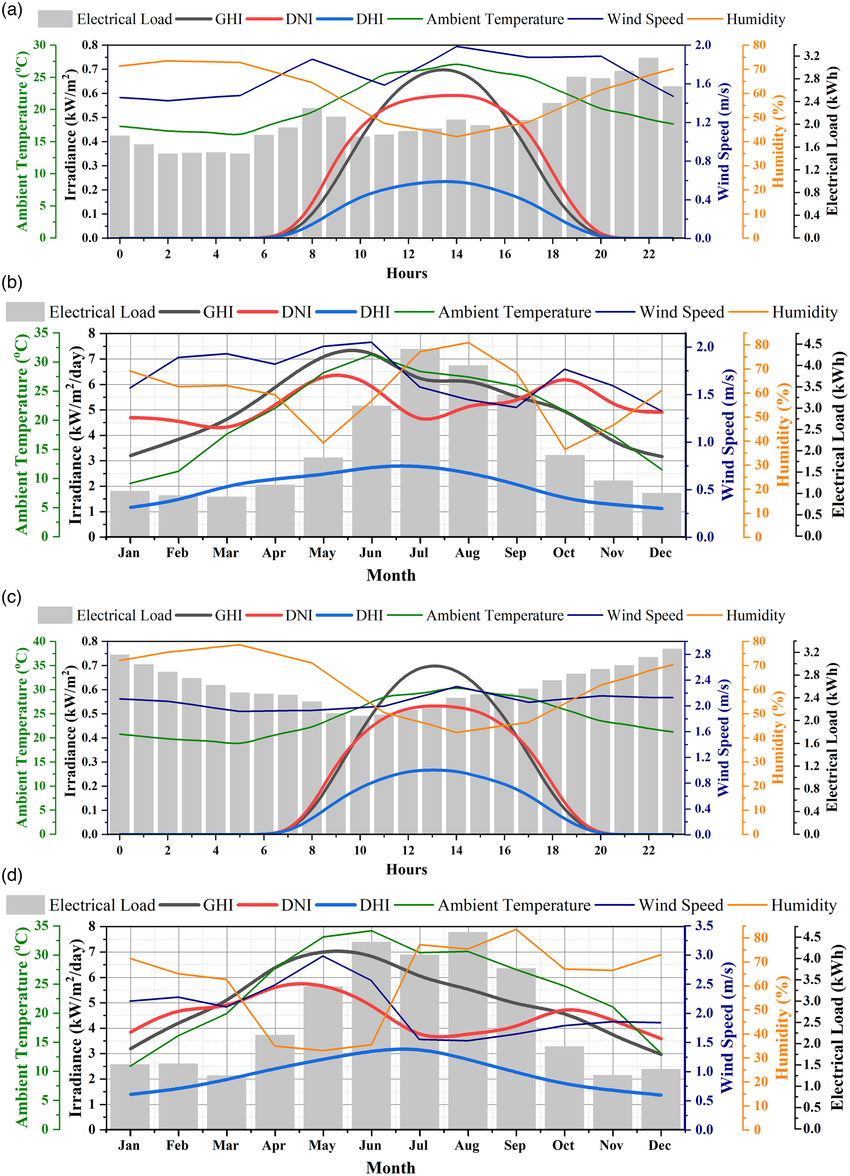

In [ ]:
# marker = dict(color="#E16941"), line=dict(color="#E16941"))

In [25]:
df[3800:5700]

,datetime,i_sc,v_oc,i_mp,v_mp,p_mp,i_x,i_xx,"Load, kW","Solar, kW",Month,Month_Num
3800,2019-06-08 09:00:00,152.051037,4187.429433,141.944894,3264.791325,463420.457374,151.714125,96.959327,65.850666,463.420457,Jun,6
3801,2019-06-08 10:00:00,156.089488,4181.237101,145.614997,3249.507779,473177.066063,155.742202,99.074736,70.125733,473.177066,Jun,6
3802,2019-06-08 11:00:00,157.915552,4178.418021,147.272281,3242.592093,477543.934826,157.563467,100.025531,96.000000,477.543935,Jun,6
3803,2019-06-08 12:00:00,158.600207,4177.358127,147.893294,3239.998519,479174.052718,158.246305,100.381107,92.358789,479.174053,Jun,6
3804,2019-06-08 13:00:00,158.758904,4177.112229,148.037211,3239.397304,479551.342906,158.404580,100.463456,78.368884,479.551343,Jun,6
...,...,...,...,...,...,...,...,...,...,...,...,...
5695,2019-08-26 08:00:00,121.615674,4231.626796,114.080749,3378.881695,385465.355888,121.349587,80.420189,51.492688,385.465356,Aug,8
5696,2019-08-26 09:00:00,140.262523,4205.126429,131.194006,3309.272046,434156.656995,139.954322,90.681591,52.054683,434.156657,Aug,8
5697,2019-08-26 10:00:00,149.306944,4191.601752,139.447277,3275.165654,456712.933747,148.976910,95.511827,89.866838,456.712934,Aug,8
5698,2019-08-26 11:00:00,153.766032,4184.807077,143.504285,3258.302989,467580.440707,153.424753,97.859814,110.777384,467.580441,Aug,8


In [16]:
BESS.get_passport_parameters()

{'Номинальная энергоемкость, кВт·ч': 176,
 'Максимальная степень заряда (СЗ_макс), %': 100.0,
 'Минимальная степень заряда (СЗ_мин), %': 20.0,
 'Номинальная мощность заряда, кВт': 176,
 'Номинальная мощность разряда, кВт': 176,
 'Эффективность заряда, %': 98.0,
 'Эффективность разряда, %': 98.0,
 'Коэффициент саморазряда, %': 2.0,
 'Потери мощности при заряде, кВт': 7.04,
 'Потери мощности при разряде, кВт': 7.11}

In [52]:
res_2['p_bess_history']

array([0., 0., 0., ..., 0., 0., 0.])

In [14]:
kWh = np.sum(res_2['p_bess_history'][res_2['p_bess_history'] > 0])
kWh

np.float64(31244.762284250926)

In [15]:
value = 85
LIFE_SPAN = 30
capacityCapitalCost = 85 * value
powerCapitalCost = 650 * value
powerOperationCost = 0.005
capacityOperationCost = 0.02
CAPEX = (capacityCapitalCost * CAPACITY + powerCapitalCost * R_POWER_CH) * 1e-3
OPEX = np.ones(LIFE_SPAN) * capacityOperationCost * CAPEX
print(f'CAPEX={CAPEX}\nOPEX={OPEX}')

CAPEX=10995.6
OPEX=[219.912 219.912 219.912 219.912 219.912 219.912 219.912 219.912 219.912
 219.912 219.912 219.912 219.912 219.912 219.912 219.912 219.912 219.912
 219.912 219.912 219.912 219.912 219.912 219.912 219.912 219.912 219.912
 219.912 219.912 219.912]


In [16]:
cost = ((res_3['cost_dgs_history'].sum() - res_2['cost_dgs_history'].sum()) *1e-3) #тыс. руб.
cost

np.float64(429.09019302254916)

In [24]:
CAPEX

10995.6

In [25]:
OPEX

array([219.912, 219.912, 219.912, 219.912, 219.912, 219.912, 219.912,
       219.912, 219.912, 219.912, 219.912, 219.912, 219.912, 219.912,
       219.912, 219.912, 219.912, 219.912, 219.912, 219.912, 219.912,
       219.912, 219.912, 219.912, 219.912, 219.912, 219.912, 219.912,
       219.912, 219.912])

In [41]:
res_3['cost_dgs_history'].sum()

np.float64(12369351.863820214)

In [34]:
res_2['cost_dgs_history'].sum()

np.float64(11940261.670797665)

In [18]:
kWh

np.float64(31244.762284250926)

In [19]:
s

np.float64(429.09019302254916)

In [17]:
from src.financial import Economy
inflation = 5.58/100
s = ((res_3['cost_dgs_history'].sum() - res_2['cost_dgs_history'].sum()) *1e-3)
electricity_prices = 19.8/100
Ec = Economy.Economy(30,0.145)
Ec.LCOS_calc(capex=CAPEX,
             opex=OPEX,
             kWh=kWh,
             s=s,
             i=inflation,
             e=electricity_prices
             )


-0.047802498341808296

In [20]:
import numpy as np

from src.components.Battery import Battery
from src.components.DieselGenerator import DieselGenerator
from src.simulator.MicrogridSimulator import MicrogridSimulator
from src.financial import Economy


def fitness_func(x):
    battery_params = {
        'capacity': x[0],
        'soc_max': 100,
        'soc_min': 20,
        'r_power_ch': x[1],
        'r_power_ds': x[1],
        'eff_ch': 98,
        'eff_ds': 98,
        'cp': 2,
    }

    dg_params = {
        'num_DGs': 4,
        'gen_capacity': 110,
        'a1': 0.0101,
        'a2': 0.2654,
        'fuel_price': 54.6,
    }

    value = 85
    lifespan = 30

    capex = (
        85 * value * battery_params['capacity']
        + 650 * value * battery_params['r_power_ch']
    ) * 1e-3 # тыс.руб
    opex = np.ones(lifespan) * 0.002 * capex # тыс.руб

    simulator = MicrogridSimulator(
        df,
        'Сасыр, kW',
        'Solar, kW',
        Battery(**battery_params),
        DieselGenerator(**dg_params),
    )

    end = simulator.simulator_2(
        initial_soc=0.5,
        val_dgs=np.array([1, 1, 0, 0], dtype=np.float64),
    )
    # kwh = np.abs(end['p_bess_history']).sum()
    kwh = np.sum(end['p_bess_history'][end['p_bess_history'] > 0])
    if kwh == 0:
        return 1e9
    start = 11731002.822741086

    savings = (
        start
        - end['cost_dgs_history'].sum()
    ) * 1e-3 # тыс.руб

    lcos = Economy.Economy(30, 0.145).LCOS_calc(
        capex=capex, # тыс.руб
        opex=opex, # тыс.руб
        kWh=kwh,  # кВтч
        s=savings, # тыс.руб
        i=5.58 / 100,
        e=19.8 / 100,
    )
    return -lcos

In [ ]:
import numpy as np
import math
from pymoo.algorithms.moo.nsga2 import RankAndCrowdingSurvival
from src.simulator.Optimization.Optimization import OptProblem
from pymoo.core.mixed import MixedVariableGA
from pymoo.optimize import minimize


lb = [38.5, 1]
ub = [1000, 1000]
problem = OptProblem(
    objective=fitness_func,
    lower_bound=int(math.ceil(lb[0])),   # 39
    upper_bound=int(ub[0]),              # 1000
    iteration_log_interval=1
)
method = MixedVariableGA(
    pop_size=100,
    survival=RankAndCrowdingSurvival()
)

res = minimize(
    problem,
    method,
    termination=('n_gen', 60),
    seed=1,
    save_history=True
)

print(f'Лучшее значение ф-и {res.F} при параметрах {res.X}')
print(f'LCOS ={res.F[0] * 1e+3:.3f}руб./кВт·ч')
print(f'LCOS ={res.F[0] * 1e+6 / 85:.3f}$/MWh')

[   0] LCOS=3.447 руб/кВт·ч; best=3.447
[   1] LCOS=-22.220 руб/кВт·ч; best=-22.220
[   2] LCOS=-17.438 руб/кВт·ч; best=-22.220
[   3] LCOS=-21.720 руб/кВт·ч; best=-22.220
[   4] LCOS=-304.029 руб/кВт·ч; best=-304.029
[   5] LCOS=-87.656 руб/кВт·ч; best=-304.029
[   6] LCOS=-18.149 руб/кВт·ч; best=-304.029
[   7] LCOS=-21.541 руб/кВт·ч; best=-304.029
[   8] LCOS=-32.685 руб/кВт·ч; best=-304.029
[   9] LCOS=-17.311 руб/кВт·ч; best=-304.029
[  10] LCOS=15.915 руб/кВт·ч; best=-304.029
[  11] LCOS=-1.273 руб/кВт·ч; best=-304.029
[  12] LCOS=-25.956 руб/кВт·ч; best=-304.029
[  13] LCOS=-18.179 руб/кВт·ч; best=-304.029
[  14] LCOS=-53.309 руб/кВт·ч; best=-304.029
[  15] LCOS=-29.524 руб/кВт·ч; best=-304.029
[  16] LCOS=-18.102 руб/кВт·ч; best=-304.029
[  17] LCOS=-20.736 руб/кВт·ч; best=-304.029
[  18] LCOS=-150.638 руб/кВт·ч; best=-304.029
[  19] LCOS=-330.107 руб/кВт·ч; best=-330.107
[  20] LCOS=-19.016 руб/кВт·ч; best=-330.107
[  21] LCOS=15.209 руб/кВт·ч; best=-330.107
[  22] LCOS=-18.44

In [1]:
fitness_func([165,165])

NameError: name 'fitness_func' is not defined

In [52]:
print(f'LCOS = {res.F[0] * 1e+3:.2f} руб./кВт·ч')
print(f'LCOS = {res.F[0] * 1e+6 / 85:.2f} $/MWh')

LCOS =24.837руб./кВт·ч
LCOS =292.204$/MWh
